#**MAJOR PROJECT**
**Build and evaluate time series models to forecast the
number of confirmed COVID-19 cases over time, at both the country and WHO
region level. The focus will be on using ARIMA and SARIMAX models to capture
trends and seasonal patterns in the data and to compare their performance.**

* Data set link:/content/covid_19_clean_complete (1).csv



#**Importing necessary libraries**

In [ ]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as pmat
import seaborn as sea
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.seasonal import seasonal_decompose

#**Inspecting raw data**

In [ ]:
de=pd.read_csv(r'/content/covid_19_clean_complete.csv')
de.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [ ]:
de.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


**insights**

* there are 49068 rows,10 coloumns(Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region).

* only the coloumn province/state has null values in most entries.

#**Data preprocessing**

*As there many coloums are of object type and there are a lot of null values in the coloumn "Province/State".they must be processed except the coloumn"date" the and must be hot encoded for the models to understand.

*the null values in the "Province/State" will be give the obect value "uk" and then will be hot encoded



In [ ]:
from sklearn.preprocessing import LabelEncoder

lcodr = LabelEncoder()
cv = list(de.columns)
d = dict()

for i in cv:
    if de[i].dtype == 'object' and i!='Date':
        if not de[i].mode().empty:
            de[i] = de[i].fillna(de[i].mode()[0])
        else:
            de[i] = de[i].fillna('uk')


        de[i] = lcodr.fit_transform(de[i])

        mapping = {label: idx for idx, label in enumerate(lcodr.classes_)}
        d[i] = mapping

print(d)




{'Province/State': {'Alberta': 0, 'Anguilla': 1, 'Anhui': 2, 'Aruba': 3, 'Australian Capital Territory': 4, 'Beijing': 5, 'Bermuda': 6, 'British Columbia': 7, 'British Virgin Islands': 8, 'Cayman Islands': 9, 'Channel Islands': 10, 'Chongqing': 11, 'Curacao': 12, 'Falkland Islands (Malvinas)': 13, 'Faroe Islands': 14, 'French Guiana': 15, 'French Polynesia': 16, 'Fujian': 17, 'Gansu': 18, 'Gibraltar': 19, 'Greenland': 20, 'Guadeloupe': 21, 'Guangdong': 22, 'Guangxi': 23, 'Guizhou': 24, 'Hainan': 25, 'Hebei': 26, 'Heilongjiang': 27, 'Henan': 28, 'Hong Kong': 29, 'Hubei': 30, 'Hunan': 31, 'Inner Mongolia': 32, 'Isle of Man': 33, 'Jiangsu': 34, 'Jiangxi': 35, 'Jilin': 36, 'Liaoning': 37, 'Macau': 38, 'Manitoba': 39, 'Martinique': 40, 'Mayotte': 41, 'Montserrat': 42, 'New Brunswick': 43, 'New Caledonia': 44, 'New South Wales': 45, 'Newfoundland and Labrador': 46, 'Ningxia': 47, 'Northern Territory': 48, 'Northwest Territories': 49, 'Nova Scotia': 50, 'Ontario': 51, 'Prince Edward Island': 

In [ ]:
de

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,0,0,33.939110,67.709953,2020-01-22,0,0,0,0,2
1,0,1,41.153300,20.168300,2020-01-22,0,0,0,0,3
2,0,2,28.033900,1.659600,2020-01-22,0,0,0,0,0
3,0,3,42.506300,1.521800,2020-01-22,0,0,0,0,3
4,0,4,-11.202700,17.873900,2020-01-22,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
49063,0,144,0.186400,6.613100,2020-07-27,865,14,734,117,0
49064,0,184,15.552727,48.516388,2020-07-27,1691,483,833,375,2
49065,0,38,-11.645500,43.333300,2020-07-27,354,7,328,19,0
49066,0,165,38.861000,71.276100,2020-07-27,7235,60,6028,1147,3


* the objects are now hot encoded except 'date'.
* 'date' coloumn was'nt encoded as it can be converted into to an pandas data type wich models can use

In [ ]:
de['Date']=pd.to_datetime(de['Date'])
de

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,0,0,33.939110,67.709953,2020-01-22,0,0,0,0,2
1,0,1,41.153300,20.168300,2020-01-22,0,0,0,0,3
2,0,2,28.033900,1.659600,2020-01-22,0,0,0,0,0
3,0,3,42.506300,1.521800,2020-01-22,0,0,0,0,3
4,0,4,-11.202700,17.873900,2020-01-22,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
49063,0,144,0.186400,6.613100,2020-07-27,865,14,734,117,0
49064,0,184,15.552727,48.516388,2020-07-27,1691,483,833,375,2
49065,0,38,-11.645500,43.333300,2020-07-27,354,7,328,19,0
49066,0,165,38.861000,71.276100,2020-07-27,7235,60,6028,1147,3


In [ ]:
de.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  49068 non-null  int64         
 1   Country/Region  49068 non-null  int64         
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(7)
memory usage: 3.7 MB


#**Creation of a Seperate Dataset**
* now as the data is processed,we are going to take

In [ ]:

'''de2=de[['Date','Confirmed']].copy()

de2.set_index('Date',inplace=True)
decom=seasonal_decompose(de2['Confirmed'])
print(decom.plot())'''

"de2=de[['Date','Confirmed']].copy()\n\nde2.set_index('Date',inplace=True)\ndecom=seasonal_decompose(de2['Confirmed'])\nprint(decom.plot())"

In [ ]:
de

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,0,0,33.939110,67.709953,2020-01-22,0,0,0,0,2
1,0,1,41.153300,20.168300,2020-01-22,0,0,0,0,3
2,0,2,28.033900,1.659600,2020-01-22,0,0,0,0,0
3,0,3,42.506300,1.521800,2020-01-22,0,0,0,0,3
4,0,4,-11.202700,17.873900,2020-01-22,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
49063,0,144,0.186400,6.613100,2020-07-27,865,14,734,117,0
49064,0,184,15.552727,48.516388,2020-07-27,1691,483,833,375,2
49065,0,38,-11.645500,43.333300,2020-07-27,354,7,328,19,0
49066,0,165,38.861000,71.276100,2020-07-27,7235,60,6028,1147,3


**insight**
*the above error means that during some dates,the confired cases are null..asfreq('D') and fillna can be used to fix this


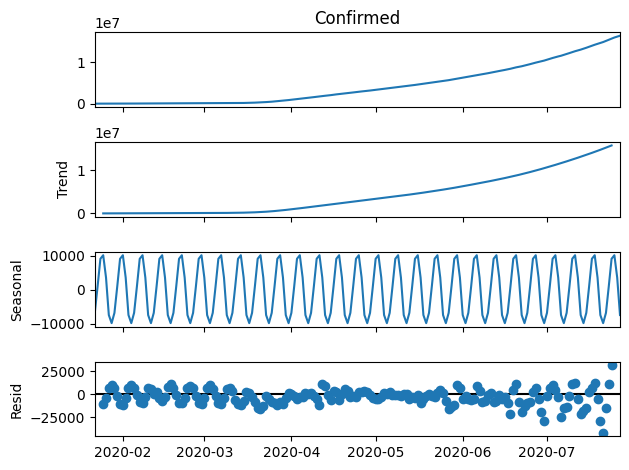

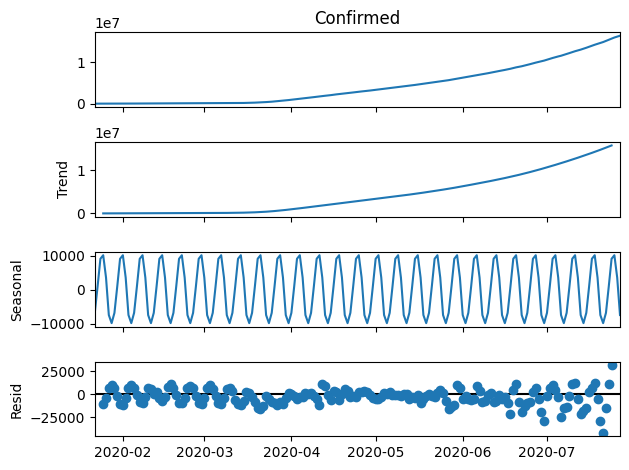

In [ ]:


# Step 1: Copy and convert date
de3 = de[['Date', 'Confirmed', 'WHO Region']].copy()
de3['Date'] = pd.to_datetime(de3['Date'])

# Step 2: One-hot encode WHO Region
who_dummies = pd.get_dummies(de3['WHO Region'], prefix='WHO')

# Step 3: Combine Confirmed + WHO columns
de3_with_dummies = pd.concat([de3[['Date', 'Confirmed']], who_dummies], axis=1)
dx=de3_with_dummies.copy()

# Step 4: Aggregate by Date
# -> Confirmed = sum of cases
# -> WHO dummies = sum (so we know how many reports came from each region that day)
de3_daily = de3_with_dummies.groupby(['Date']).sum()

# Step 5: Ensure daily frequency
de3_daily = de3_daily.asfreq('D').fillna(0)

# Step 6: Seasonal decomposition on Confirmed
decom = seasonal_decompose(de3_daily['Confirmed'], model='additive')
decom.plot()



In [ ]:
dx

,Date,Confirmed,WHO_0,WHO_1,WHO_2,WHO_3,WHO_4,WHO_5
0,2020-01-22,0,False,False,True,False,False,False
1,2020-01-22,0,False,False,False,True,False,False
2,2020-01-22,0,True,False,False,False,False,False
3,2020-01-22,0,False,False,False,True,False,False
4,2020-01-22,0,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
49063,2020-07-27,865,True,False,False,False,False,False
49064,2020-07-27,1691,False,False,True,False,False,False
49065,2020-07-27,354,True,False,False,False,False,False
49066,2020-07-27,7235,False,False,False,True,False,False


In [ ]:
col=[c for c in dx.columns if c.startswith('WHO_')]
col

['WHO_0', 'WHO_1', 'WHO_2', 'WHO_3', 'WHO_4', 'WHO_5']

In [ ]:
dx['region']=dx[col].idxmax(axis=1)
dx

,Date,Confirmed,WHO_0,WHO_1,WHO_2,WHO_3,WHO_4,WHO_5,region
0,2020-01-22,0,False,False,True,False,False,False,WHO_2
1,2020-01-22,0,False,False,False,True,False,False,WHO_3
2,2020-01-22,0,True,False,False,False,False,False,WHO_0
3,2020-01-22,0,False,False,False,True,False,False,WHO_3
4,2020-01-22,0,True,False,False,False,False,False,WHO_0
...,...,...,...,...,...,...,...,...,...
49063,2020-07-27,865,True,False,False,False,False,False,WHO_0
49064,2020-07-27,1691,False,False,True,False,False,False,WHO_2
49065,2020-07-27,354,True,False,False,False,False,False,WHO_0
49066,2020-07-27,7235,False,False,False,True,False,False,WHO_3


In [ ]:
dx=dx.drop(columns=col)
dx

,Date,Confirmed,region
0,2020-01-22,0,WHO_2
1,2020-01-22,0,WHO_3
2,2020-01-22,0,WHO_0
3,2020-01-22,0,WHO_3
4,2020-01-22,0,WHO_0
...,...,...,...
49063,2020-07-27,865,WHO_0
49064,2020-07-27,1691,WHO_2
49065,2020-07-27,354,WHO_0
49066,2020-07-27,7235,WHO_3


# Data Stationary Test and Stabilization(ADF Test)
* now since  the data is preprocessed,it is to be checked if the data is stationary or not,and if its sationary level wrt to the adf test is found not to be of optimal level,it will be stabilized and be made noise free with diff,log transform.

* as per for the ease of achiving the objectives of the project,the dataframe will be seperated on the basis of WHO regions and the adf test and stabilization fns will be done on them seperately.



In [ ]:
reg_dfs={}
for r in dx['region'].unique():
  r_df=dx[dx['region']==r].copy()
  r_df = r_df.groupby('Date')['Confirmed'].sum().sort_index()
  r_df=r_df.asfreq('D').fillna(0)
  r_df=r_df.reset_index()
  r_df['NewConfirmed'] = r_df['Confirmed'].diff().fillna(0)
  globals()[f"{r}_df"]=r_df[['Date','Confirmed','NewConfirmed']]
  x=f'{r}_df'
  reg_dfs[r] =x

print(reg_dfs)



{'WHO_2': 'WHO_2_df', 'WHO_3': 'WHO_3_df', 'WHO_0': 'WHO_0_df', 'WHO_1': 'WHO_1_df', 'WHO_5': 'WHO_5_df', 'WHO_4': 'WHO_4_df'}


In [ ]:
from statsmodels.tsa.stattools import adfuller
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  if df['NewConfirmed'].nunique()<=1:
    print(f'\n{df} has const values for new confirmed cases coloumn')
  else:
    res=adfuller(df['NewConfirmed'])
    p=res[1]
    if p<= 0.05:
      print(df)
      print(f'\n{x} has Null hypothesis rejected --> data = stationary')
    else:
      print(df)
      print(f'\n{x} has Null hypothesis not rejected --> data != stationary')


          Date  Confirmed  NewConfirmed
0   2020-01-22          0           0.0
1   2020-01-23          0           0.0
2   2020-01-24          0           0.0
3   2020-01-25          0           0.0
4   2020-01-26          0           0.0
..         ...        ...           ...
183 2020-07-23    1439937       13083.0
184 2020-07-24    1453830       13893.0
185 2020-07-25    1467209       13379.0
186 2020-07-26    1478334       11125.0
187 2020-07-27    1490744       12410.0

[188 rows x 3 columns]

WHO_2_df has Null hypothesis not rejected --> data != stationary
          Date  Confirmed  NewConfirmed
0   2020-01-22          0           0.0
1   2020-01-23          0           0.0
2   2020-01-24          2           2.0
3   2020-01-25          3           1.0
4   2020-01-26          3           0.0
..         ...        ...           ...
183 2020-07-23    3216701       27307.0
184 2020-07-24    3239712       23011.0
185 2020-07-25    3259047       19335.0
186 2020-07-26    3277229     

**insight**
* df of all who regions are not stationary.therefore,they must be stabilized.
* before satbilizing ,lets see the resons of non stationary of these dataframes by visualizing their rolling mean and std fns

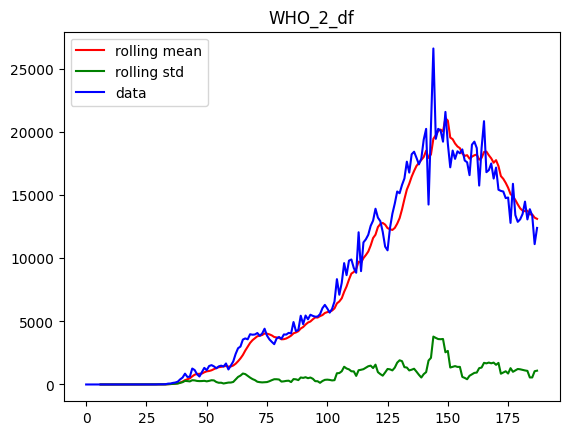

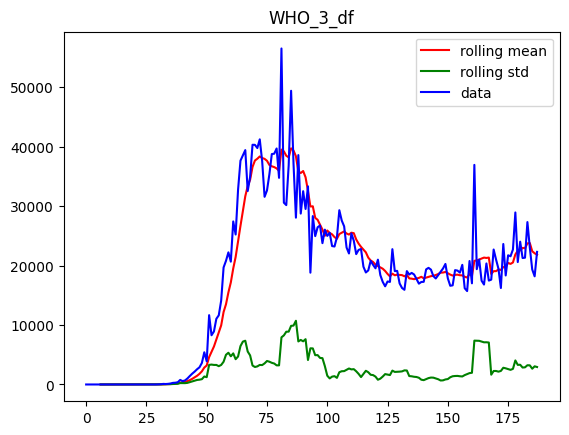

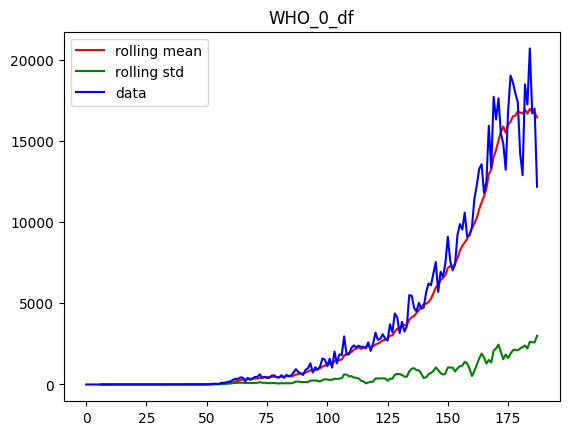

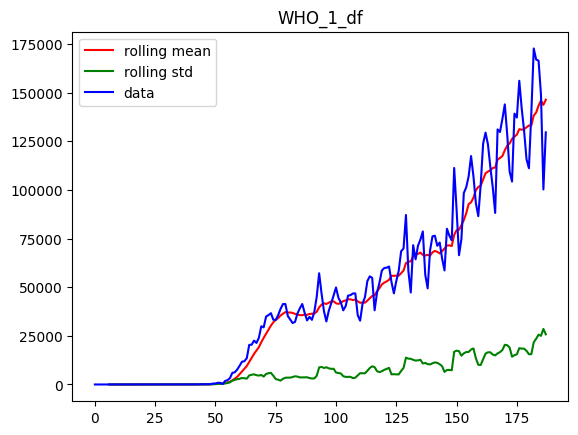

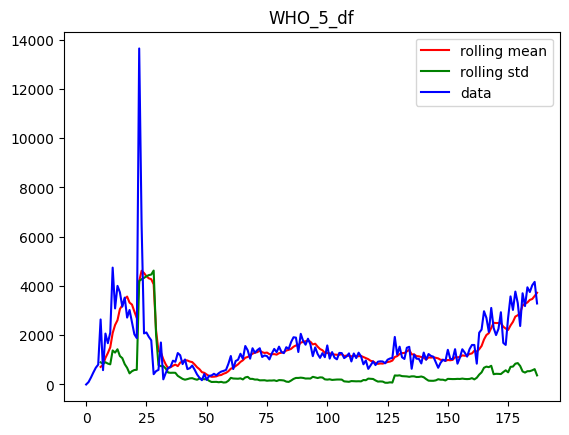

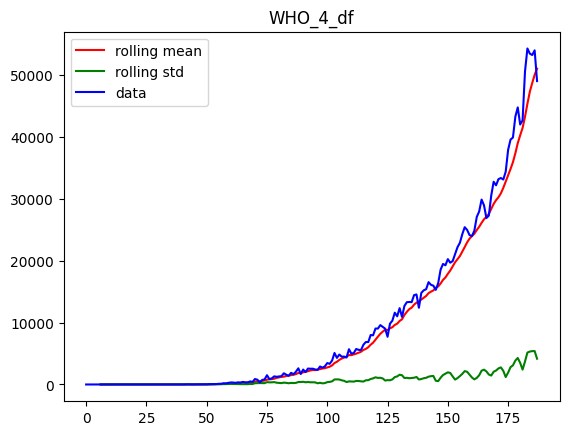

In [ ]:
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  rm=df['NewConfirmed'].rolling(window=7).mean()
  rstd=df['NewConfirmed'].rolling(window=7).std()
  df['NewConfirmed'] = df['NewConfirmed'].clip(lower=0)
  df['Confirmed'] = df['Confirmed'].clip(lower=0)
  pmat.plot(rm,color='red')
  pmat.plot(rstd,color='green')
  pmat.plot(df['NewConfirmed'].dropna(),color='blue')
  pmat.legend(['rolling mean','rolling std','data'])
  pmat.title(f'{x}')
  pmat.show()


**insight:**
* all dataframes show variying variance and mean and have trends and seasonality.

* while all dfs have to be log transformed and differenciated,each df ahs there own unique set of problems
WHO_0_df → Upward trend with rising variance.

WHO_1_df → Strong upward trend, seasonal oscillations, heteroskedastic,needs sesonal differecing too.

WHO_2_df → Sharp rise–fall with volatility spikes.

WHO_3_df → Early big spike then flatter high variance.

WHO_4_df → Exponential growth, variance rising.

WHO_5_df → Noisy, flat mean but unstable variance.


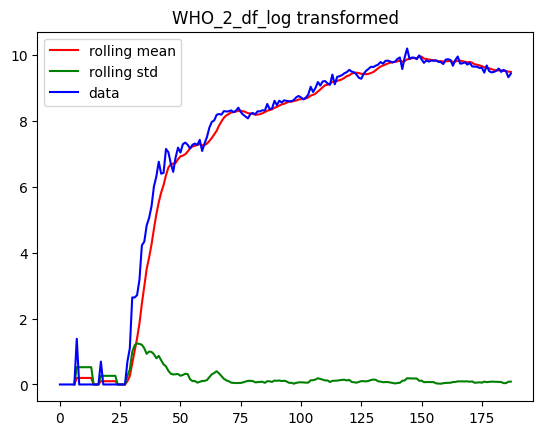

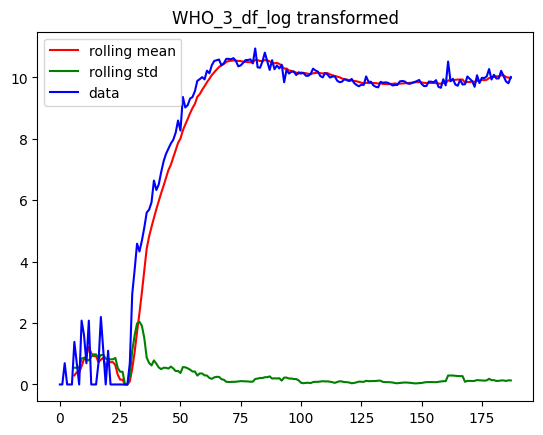

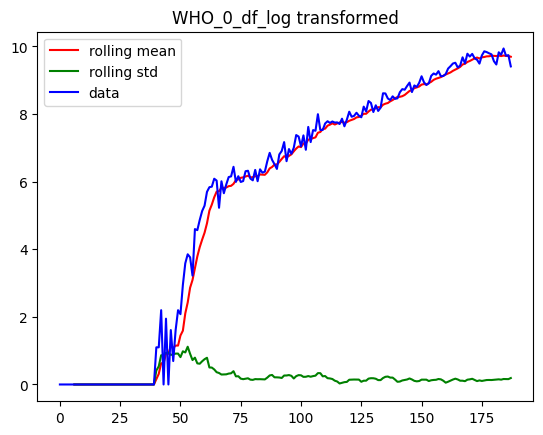

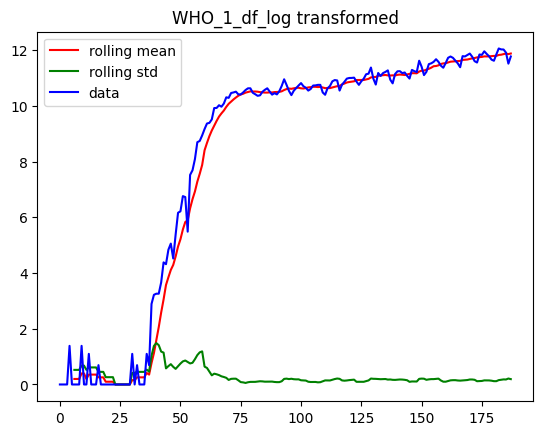

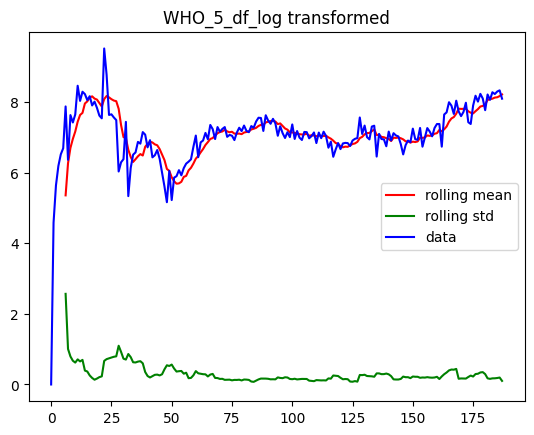

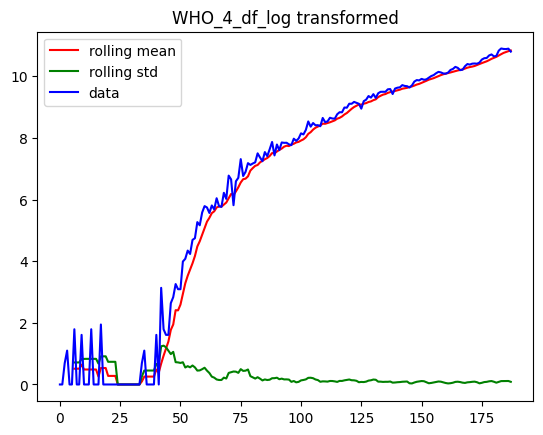

In [ ]:
lreg_dfs={}
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  ncol=[v for v in df.columns if v!='Date']
  df[ncol] = df[ncol].apply(pd.to_numeric, errors='coerce')
  df[ncol]= df[ncol].replace(0, ny.nan)
  df[ncol]= df[ncol].apply(ny.log).fillna(0)
  df['NewConfirmed'] = df['NewConfirmed'].clip(lower=0)
  df['Confirmed'] = df['Confirmed'].clip(lower=0)
  rm=df['NewConfirmed'].rolling(window=7).mean()
  rstd=df['NewConfirmed'].rolling(window=7).std()
  pmat.plot(rm,color='red')
  pmat.plot(rstd,color='green')
  pmat.plot(df['NewConfirmed'].dropna(),color='blue')
  pmat.legend(['rolling mean','rolling std','data'])
  pmat.title(f'{x}_log transformed')
  pmat.show()

**insights**
* in all dfs the variance is stabilized but the raw data and avg is still not stable enough,for differnecing must be used.

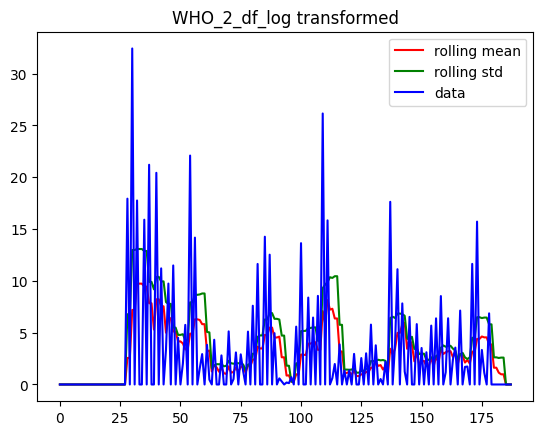

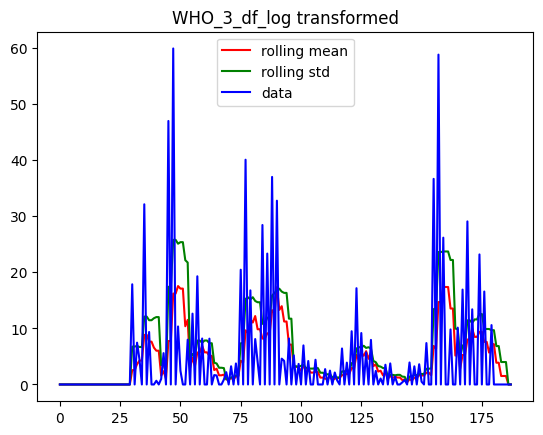

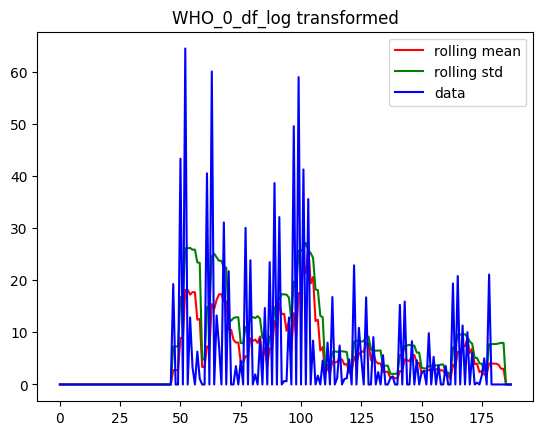

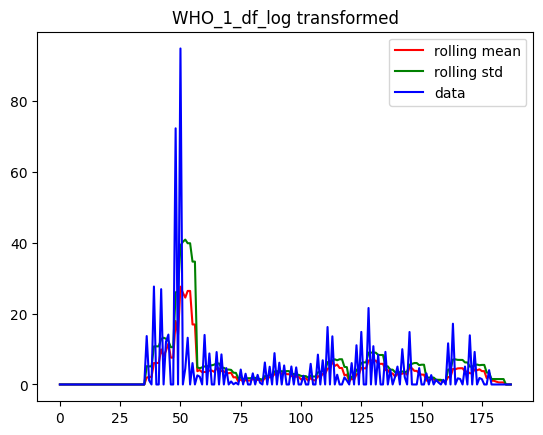

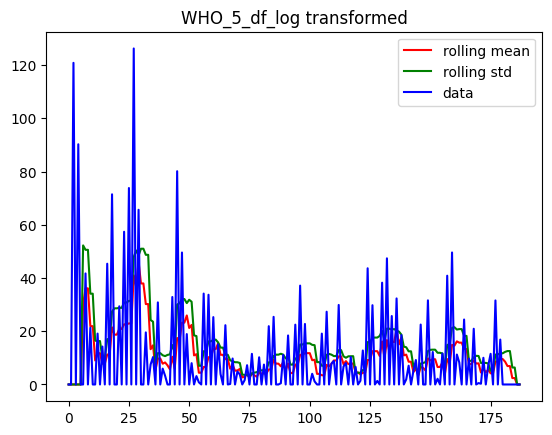

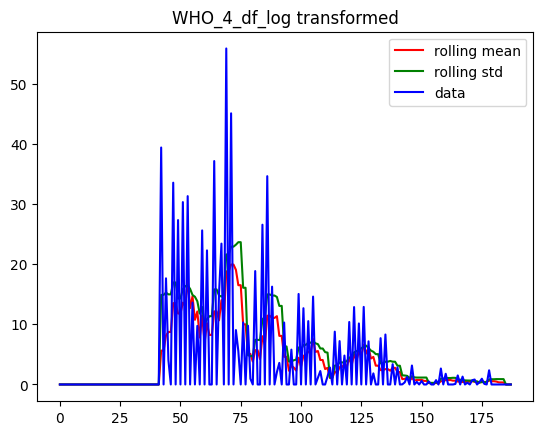

In [ ]:
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  ncol=[v for v in df.columns if v!='Date']
  df[ncol] = df[ncol].apply(pd.to_numeric, errors='coerce')
  df[ncol]= df[ncol].replace(0, ny.nan)
  df[ncol]= df[ncol].apply(ny.diff).dropna()
  df[ncol]= df[ncol].apply(lambda x:ny.diff(x,n=7)).fillna(0)
  df[ncol] = df[ncol].replace([ny.inf, -ny.inf], ny.nan)
  df[ncol] = df[ncol].fillna(0)
  df['NewConfirmed'] = df['NewConfirmed'].clip(lower=0)
  df['Confirmed'] = df['Confirmed'].clip(lower=0)
  rm=df['NewConfirmed'].rolling(window=7).mean().fillna(0)
  rstd=df['NewConfirmed'].rolling(window=7).std().fillna(0)
  pmat.plot(rm,color='red')
  pmat.plot(rstd,color='green')
  pmat.plot(df['NewConfirmed'].dropna(),color='blue')
  pmat.legend(['rolling mean','rolling std','data'])
  pmat.title(f'{x}_log transformed')
  pmat.show()

In [ ]:
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  print(f"\n{rgn}")
  print(df)


WHO_2
          Date  Confirmed  NewConfirmed
0   2020-01-22        0.0           0.0
1   2020-01-23        0.0           0.0
2   2020-01-24        0.0           0.0
3   2020-01-25        0.0           0.0
4   2020-01-26        0.0           0.0
..         ...        ...           ...
183 2020-07-23        0.0           0.0
184 2020-07-24        0.0           0.0
185 2020-07-25        0.0           0.0
186 2020-07-26        0.0           0.0
187 2020-07-27        0.0           0.0

[188 rows x 3 columns]

WHO_3
          Date  Confirmed  NewConfirmed
0   2020-01-22        0.0           0.0
1   2020-01-23        0.0           0.0
2   2020-01-24        0.0           0.0
3   2020-01-25        0.0           0.0
4   2020-01-26        0.0           0.0
..         ...        ...           ...
183 2020-07-23        0.0           0.0
184 2020-07-24        0.0           0.0
185 2020-07-25        0.0           0.0
186 2020-07-26        0.0           0.0
187 2020-07-27        0.0           0.0

[

**insights**
* now all the dfs are log transformed and differenciated,lets test them with adf test again

In [ ]:
from statsmodels.tsa.stattools import adfuller
un_dfs={}
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  if df['NewConfirmed'].nunique()<=1:
    print(f'\n{df} has const values for new confirmed cases coloumn')
  else:
    res=adfuller(df['NewConfirmed'])
    p=res[1]
    if p<= 0.05:
      print(f'\n{x} has Null hypothesis rejected --> data = stationary\n')
    else:
      print(f'\n{x} has Null hypothesis not rejected --> data != stationary\n')
      un_dfs[rgn]=f"{x}"
print(un_dfs)


WHO_2_df has Null hypothesis rejected --> data = stationary


WHO_3_df has Null hypothesis rejected --> data = stationary


WHO_0_df has Null hypothesis not rejected --> data != stationary


WHO_1_df has Null hypothesis rejected --> data = stationary


WHO_5_df has Null hypothesis rejected --> data = stationary


WHO_4_df has Null hypothesis not rejected --> data != stationary

{'WHO_0': 'WHO_0_df', 'WHO_4': 'WHO_4_df'}


**insights**

* only dfs WHO_2_df,WHO_5_df became stationary.
* to stabilze the data of  rest of the dfs,additional differeciating must be done.this time,higher order differencing.

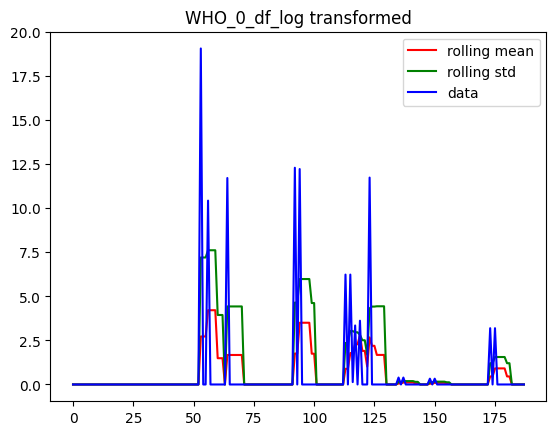

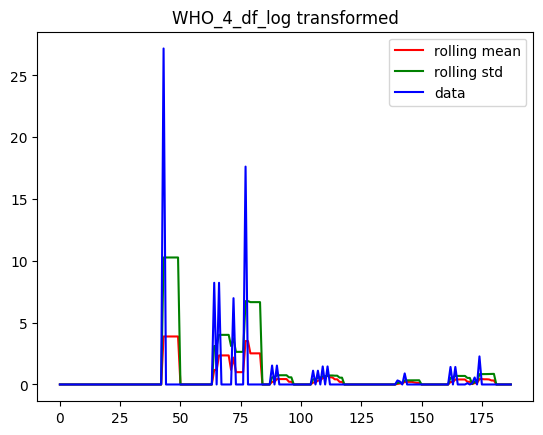

In [ ]:
for rgn,df in un_dfs.items():
  x=df
  df=globals()[df]
  ncol=[v for v in df.columns if v!='Date']
  df[ncol] = df[ncol].apply(pd.to_numeric, errors='coerce')
  df[ncol]= df[ncol].replace(0, ny.nan)
  df[ncol]= df[ncol].apply(ny.diff).fillna(0)
  df[ncol]= df[ncol].apply(lambda x:ny.diff(x,n=2)).fillna(0)
  df[ncol] = df[ncol].replace([ny.inf, -ny.inf], ny.nan)
  df[ncol] = df[ncol].fillna(0)
  df['NewConfirmed'] = df['NewConfirmed'].clip(lower=0)
  df['Confirmed'] = df['Confirmed'].clip(lower=0)
  rm=df['NewConfirmed'].rolling(window=7).mean().fillna(0)
  rstd=df['NewConfirmed'].rolling(window=7).std().fillna(0)
  pmat.plot(rm,color='red')
  pmat.plot(rstd,color='green')
  pmat.plot(df['NewConfirmed'].dropna(),color='blue')
  pmat.legend(['rolling mean','rolling std','data'])
  pmat.title(f'{x}_log transformed')
  pmat.show()


In [ ]:
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  print(df)

          Date  Confirmed  NewConfirmed
0   2020-01-22        0.0           0.0
1   2020-01-23        0.0           0.0
2   2020-01-24        0.0           0.0
3   2020-01-25        0.0           0.0
4   2020-01-26        0.0           0.0
..         ...        ...           ...
183 2020-07-23        0.0           0.0
184 2020-07-24        0.0           0.0
185 2020-07-25        0.0           0.0
186 2020-07-26        0.0           0.0
187 2020-07-27        0.0           0.0

[188 rows x 3 columns]
          Date  Confirmed  NewConfirmed
0   2020-01-22        0.0           0.0
1   2020-01-23        0.0           0.0
2   2020-01-24        0.0           0.0
3   2020-01-25        0.0           0.0
4   2020-01-26        0.0           0.0
..         ...        ...           ...
183 2020-07-23        0.0           0.0
184 2020-07-24        0.0           0.0
185 2020-07-25        0.0           0.0
186 2020-07-26        0.0           0.0
187 2020-07-27        0.0           0.0

[188 rows x 3 c

In [ ]:
un_dfs={}
for rgn,df in reg_dfs.items():
  x=df
  df=globals()[df]
  if df['NewConfirmed'].nunique()<=1:
    print(f'\n{df} has const values for new confirmed cases coloumn')
  else:
    res=adfuller(df['NewConfirmed'])
    p=res[1]
    if p<= 0.05:
      print(f'\n{x} has Null hypothesis rejected --> data = stationary\n')
    else:
      print(f'\n{x} has Null hypothesis not rejected --> data != stationary\n')
      un_dfs[rgn]=f"{x}"
print(un_dfs)


WHO_2_df has Null hypothesis rejected --> data = stationary


WHO_3_df has Null hypothesis rejected --> data = stationary


WHO_0_df has Null hypothesis rejected --> data = stationary


WHO_1_df has Null hypothesis rejected --> data = stationary


WHO_5_df has Null hypothesis rejected --> data = stationary


WHO_4_df has Null hypothesis rejected --> data = stationary

{}


**insights**
* now all the dfs are staionary enough for training arima and sarima models.

# **ARIMA,SARIMA**

* now with the sationary data,we can now train arima and sarima models.
* but before that,wer need to fid the best p,d,q values for each df

In [ ]:
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
df_low_r={}
p = range(0, 8)
d =range(0,2)
q = range(0, 8)
pdq = list(itertools.product(p, d, q))
for rgn, df in reg_dfs.items():
    df = globals()[df]
    l = len(df)
    t = int(l * 0.8)
    tr = df['NewConfirmed'].iloc[:t]
    ts = df['NewConfirmed'].iloc[t:]
    rmse = []
    order = []
    for a_order in pdq:
        try:
            m = ARIMA(tr, order=a_order)
            mf = m.fit()
            prdt = mf.predict(start=len(tr), end=len(tr) + len(ts) - 1)
            x = np.sqrt(mean_squared_error(ts, prdt))
            rmse.append(x)
            order.append(a_order)
        except:
            continue
    r = pd.DataFrame({'order': order, 'rmse': rmse})
    best = r.loc[r['rmse'].idxmin()]
    df_low_r[f'{rgn}_df']=best['order']
print(df_low_r)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWar

{'WHO_2_df': (1, 1, 0), 'WHO_3_df': (6, 1, 6), 'WHO_0_df': (1, 1, 0), 'WHO_1_df': (4, 1, 0), 'WHO_5_df': (1, 1, 2), 'WHO_4_df': (4, 1, 1)}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(df_low_r)

{'WHO_2_df': (1, 1, 0), 'WHO_3_df': (6, 1, 6), 'WHO_0_df': (1, 1, 0), 'WHO_1_df': (4, 1, 0), 'WHO_5_df': (1, 1, 2), 'WHO_4_df': (4, 1, 1)}


**insights**
* now we have the pdq order for each df ,we can now train models accordingly to their orders respectively.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


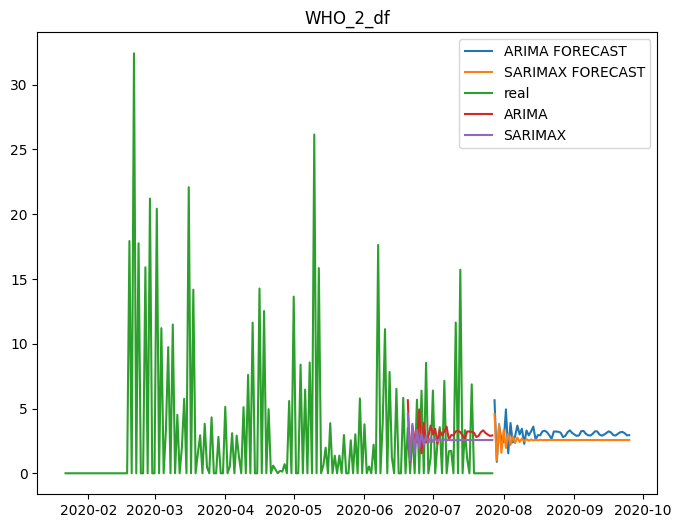

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


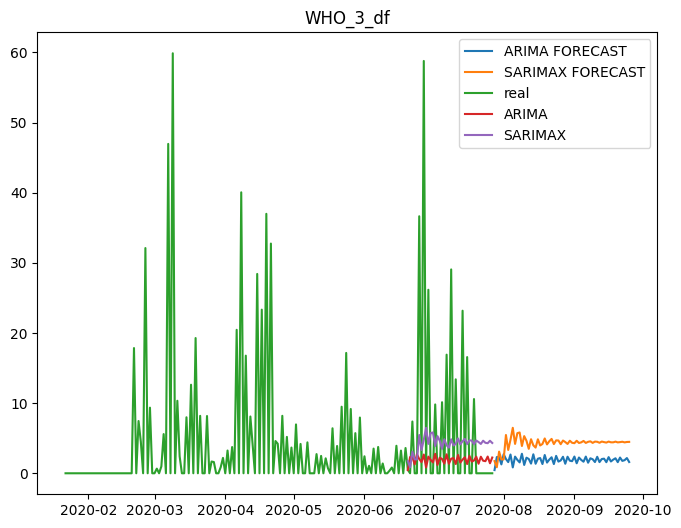

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


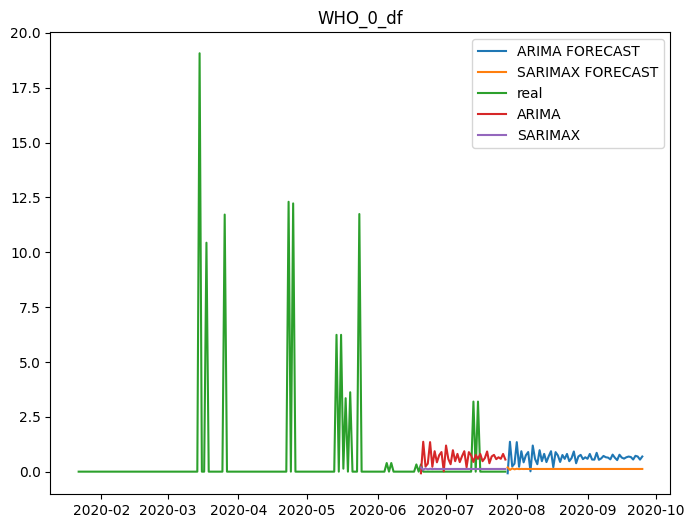

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


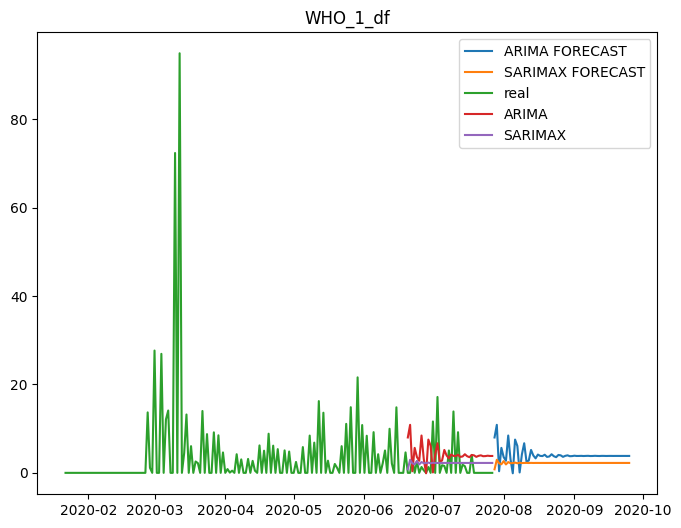

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


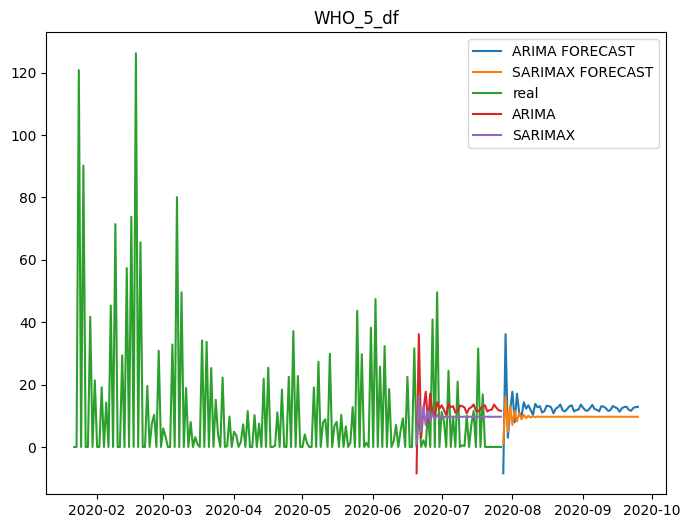

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


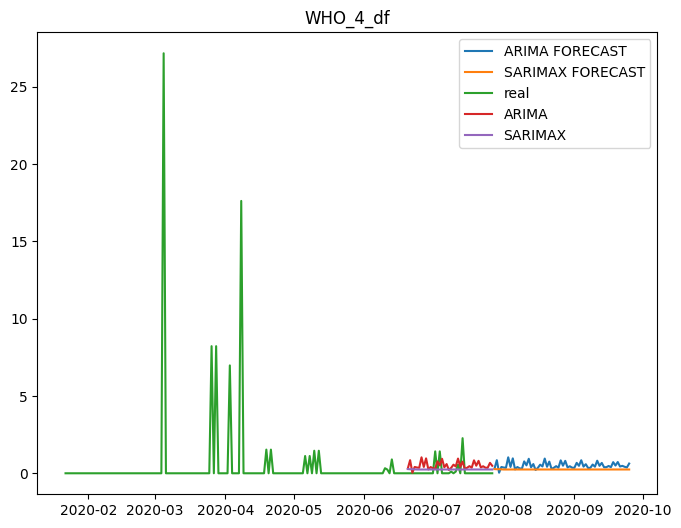

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
for df,o in df_low_r.items():
  x=df
  df=globals()[df]
  l = len(df)
  t = int(l * 0.8)
  tr = df['NewConfirmed'].iloc[:t]
  ts = df['NewConfirmed'].iloc[t:]
  m=ARIMA(tr, order=a_order)
  mf=m.fit()
  df['ARIMA']=mf.predict(start=len(tr), end=len(tr) + len(ts) - 1)
  m2=SARIMAX(tr,order=o)
  mf2=m2.fit()
  df['SARIMAX']=mf2.predict(start=len(tr), end=len(tr) + len(ts) - 1)
  f1 = mf.forecast(steps=60)
  f2 = mf2.forecast(steps=60)
  forecast_index = pd.date_range(start=df['Date'].iloc[-1] + pd.Timedelta(days=1),
                               periods=60, freq='D')
  pmat.figure(figsize=(8,6))
  pmat.plot(forecast_index, f1, label='ARIMA FORECAST')
  pmat.plot(forecast_index, f2, label='SARIMAX FORECAST')
  pmat.plot(df['Date'],df['NewConfirmed'],label='real')
  pmat.plot(df['Date'],df['ARIMA'],label='ARIMA')
  pmat.plot(df['Date'],df['SARIMAX'],label='SARIMAX')
  pmat.title(f"{x}")
  pmat.legend()
  pmat.show()



* ....